# Kombinasi 4: Econophysics Kuantum — Portfolio Optimization via HE-VQE

Pipeline lengkap integrasi **Econophysics**, **Game Theory (Markowitz Payoff)**, dan **VQE**:

1. **Data Acquisition** — 4 saham Large Cap LQ45 (BBCA, ASII, TLKM, UNVR)
2. **Markowitz × Game Theory** — Matriks payoff dengan λ endogen
3. **Parameter Hamiltonian** — h_i dari payoff marginal, J_ij via Quantum Mutual Information (QMI)
4. **Hamiltonian Ising** — H_cost + H_constraint (penalty K=2)
5. **HE-VQE + SPSA** — Hardware-Efficient Ansatz, 4 qubit, RY-RZ + CNOT chain
6. **Hasil & Analisis** — Seleksi 2 aset terbaik, Sharpe Ratio, visualisasi

**Referensi**: econophysics_kuantum.pdf, Kandala et al. (2017)

In [1]:
# 0. Setup & Imports
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")

PennyLane version: 0.44.0
NumPy version: 2.4.1


---
## Tahap 1: Data Acquisition & Pre-Selection

- Download data penutupan harian 4 saham LQ45 dari **Yahoo Finance**
- Hitung Daily Log Return: $R_t = \ln(P_t / P_{t-1})$
- Discretization ke biner: $|0\rangle$ (Naik) jika $R_t > 0$, $|1\rangle$ (Turun) jika $R_t \leq 0$

In [2]:
# 1. Data Acquisition & Pre-Selection (Data Historis via yfinance)

import yfinance as yf

# === Konfigurasi ===
tickers = ['BBCA.JK', 'ASII.JK', 'TLKM.JK', 'TPIA.JK']
K = 2           # Pilih 2 aset
penalty_A = 10.0  # Konstanta penalti
depth = 2        # Kedalaman ansatz
maxiter = 250    # Iterasi SPSA
n_shots = 4096   # Sampling shots
seed = 42

# Download data historis (5 tahun untuk backtest)
start_date = "2021-01-01"
end_date = "2026-01-01"
print(f"Downloading data for: {tickers} from {start_date} to {end_date}...")
data = yf.download(tickers, start=start_date, end=end_date, progress=False)['Close']
data = data.dropna()

print(f"Data shape: {data.shape}")
if not data.empty:
    print(f"Period: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")

# Hitung log return: R_t = ln(P_t / P_{t-1})
log_returns = np.log(data / data.shift(1)).dropna()

# Discretization: |0⟩ (Naik) jika R > 0, |1⟩ (Turun) jika R ≤ 0
binary_states = (log_returns <= 0).astype(int)

# Tampilkan statistik
print(f"\nLog Returns (sample):")
for t in tickers:
    mu = log_returns[t].mean()
    sigma = log_returns[t].std()
    up_pct = (binary_states[t] == 0).mean() * 100
    print(f"  {t}: μ = {mu:.6f}, σ = {sigma:.6f}, Naik = {up_pct:.1f}%")

Data shape: (1205, 4)
Period: 2021-01-04 to 2025-12-30

Log Returns (sample):
  BBCA.JK: μ = 0.000243, σ = 0.014596, Naik = 44.0%
  ASII.JK: μ = 0.000356, σ = 0.017428, Naik = 42.9%
  TLKM.JK: μ = 0.000215, σ = 0.018117, Naik = 44.7%
  TPIA.JK: μ = 0.000924, σ = 0.032141, Naik = 44.8%


## 2. Helper Functions & Demo Output


In [3]:
# === 1. Game Theory & Payoff Matrix Functions ===
import pennylane as qml
from scipy import linalg as la
from itertools import combinations
import numpy as np

def compute_endogenous_lambda(log_returns, tickers):
    """λ_market = σ_avg / (μ_avg + σ_avg), annualized"""
    mean_ret = log_returns[tickers].mean() * 252
    std_dev = log_returns[tickers].std() * np.sqrt(252)
    mu_avg = abs(mean_ret).mean()
    sigma_avg = std_dev.mean()
    if np.isnan(mu_avg) or np.isnan(sigma_avg) or (mu_avg + sigma_avg) == 0:
        return 0.5
    return sigma_avg / (mu_avg + sigma_avg)

def compute_markowitz_payoff_matrix(log_returns, binary_states, asset_a, asset_b, lambda_risk):
    """Calculate Markowitz payoff matrix 2x2 for a pair of assets."""
    state_A = binary_states[asset_a].values
    state_B = binary_states[asset_b].values
    ret_A = log_returns[asset_a].values
    ret_B = log_returns[asset_b].values
    
    payoff_A = np.zeros((2, 2))
    payoff_B = np.zeros((2, 2))
    counts = np.zeros((2, 2))
    
    for t in range(len(state_A)):
        i, j = int(state_A[t]), int(state_B[t])
        counts[i, j] += 1
        # Utility: (1-λ)µ - λσ
        u_A = (1 - lambda_risk) * (ret_A[t] * 252) - lambda_risk * abs(ret_A[t] * 252)
        u_B = (1 - lambda_risk) * (ret_B[t] * 252) - lambda_risk * abs(ret_B[t] * 252)
        payoff_A[i, j] += u_A
        payoff_B[i, j] += u_B
    
    # Average
    for i in range(2):
        for j in range(2):
            if counts[i, j] > 0:
                payoff_A[i, j] /= counts[i, j]
                payoff_B[i, j] /= counts[i, j]
    return payoff_A, payoff_B

def classify_game_type(payoff_A, payoff_B):
    """Classify game type based on payoff structure."""
    coord_A = (payoff_A[0, 0] > payoff_A[1, 0]) and (payoff_A[1, 1] > payoff_A[0, 1])
    coord_B = (payoff_B[0, 0] > payoff_B[0, 1]) and (payoff_B[1, 1] > payoff_B[1, 0])
    
    if coord_A and coord_B:
        return "Coordination Game"
    elif (not coord_A) and (not coord_B):
        return "Anti-Coordination Game"
    else:
        return "Mixed Strategy Game"


In [4]:
# === DEMO: Game Theory Analysis ===
# Calculate λ and Payoff Matrices for the full dataset as an example

print("--- Game Theory Analysis (Full Period) ---")
lam_demo = compute_endogenous_lambda(log_returns, tickers)
print(f"Endogenous Lambda (λ): {lam_demo:.4f}")

pairs = list(combinations(range(len(tickers)), 2))
for idx_a, idx_b in pairs:
    a, b = tickers[idx_a], tickers[idx_b]
    pA, pB = compute_markowitz_payoff_matrix(log_returns, binary_states, a, b, lam_demo)
    gtype = classify_game_type(pA, pB)
    print(f"\nPair {a} vs {b}:")
    print(f"  Game Type: {gtype}")
    print(f"  Payoff A:\n{pA}")
    print(f"  Payoff B:\n{pB}")


--- Game Theory Analysis (Full Period) ---
Endogenous Lambda (λ): 0.7489

Pair BBCA.JK vs ASII.JK:
  Game Type: Anti-Coordination Game
  Payoff A:
[[-1.78022661 -1.31724948]
 [-1.87493343 -2.61698517]]
  Payoff B:
[[-2.09898101 -2.26333899]
 [-1.74568839 -3.04761227]]

Pair BBCA.JK vs TLKM.JK:
  Game Type: Anti-Coordination Game
  Payoff A:
[[-1.73139477 -1.35704654]
 [-1.80848393 -2.67983172]]
  Payoff B:
[[-2.16854502 -2.49762389]
 [-1.57636631 -3.24452305]]

Pair BBCA.JK vs TPIA.JK:
  Game Type: Anti-Coordination Game
  Payoff A:
[[-1.71836149 -1.40884442]
 [-2.16271611 -2.49029906]]
  Payoff B:
[[-3.10124429 -4.08117851]
 [-2.65949212 -4.36984144]]

Pair ASII.JK vs TLKM.JK:
  Game Type: Anti-Coordination Game
  Payoff A:
[[-1.99283245 -1.86879289]
 [-2.24608034 -3.07685524]]
  Payoff B:
[[-2.22844432 -2.56472098]
 [-1.53887221 -3.20094241]]

Pair ASII.JK vs TPIA.JK:
  Game Type: Anti-Coordination Game
  Payoff A:
[[-2.12897062 -1.76569211]
 [-2.33967393 -3.07966407]]
  Payoff B:
[[

In [5]:
# === 2. Hamiltonian & Quantum Mutual Information ===

def compute_bias_hi(all_payoffs, tickers):
    """Calculate bias h_i from marginal payoff matrices."""
    n_assets = len(tickers)
    h = np.zeros(n_assets)
    for i in range(n_assets):
        payoff_sum = 0
        count = 0
        for (a, b), (pA, pB) in all_payoffs.items():
            if a == i:
                # Difference between state 1 and 0
                payoff_sum += (pA[1, 0] + pA[1, 1]) - (pA[0, 0] + pA[0, 1])
                count += 1
            elif b == i:
                payoff_sum += (pB[0, 1] + pB[1, 1]) - (pB[0, 0] + pB[1, 0])
                count += 1
        if count > 0:
            h[i] = payoff_sum / count
    return h

def compute_qmi_jij(binary_states, asset_a, asset_b, alpha=1.0):
    """Calculate Quantum Mutual Information (QMI) as J_ij."""
    state_A = binary_states[asset_a].values
    state_B = binary_states[asset_b].values
    N = len(state_A)
    
    n_ij = np.zeros((2, 2))
    for t in range(N):
        n_ij[int(state_A[t]), int(state_B[t])] += 1
    prob_joint = (n_ij + alpha) / (N + 4 * alpha)
    
    rho_LF = np.diag(prob_joint.flatten())
    rho_L = np.diag(prob_joint.sum(axis=1))
    rho_F = np.diag(prob_joint.sum(axis=0))
    
    def von_neumann_entropy(rho):
        eigenvalues = np.real(la.eigvalsh(rho))
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log(eigenvalues))
    
    S_LF = von_neumann_entropy(rho_LF)
    S_L = von_neumann_entropy(rho_L)
    S_F = von_neumann_entropy(rho_F)
    return S_L + S_F - S_LF


In [6]:
def build_hamiltonian(h, J, n_assets, K=2, penalty_A=10.0):
    """Build total Hamiltonian = H_cost + H_constraint"""
    coeffs = []
    obs = []
    
    # H_cost terms
    for i in range(n_assets):
        if abs(h[i]) > 1e-10:
            coeffs.append(float(h[i]))
            obs.append(qml.PauliZ(i))
    
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            if abs(J[i, j]) > 1e-10:
                coeffs.append(float(J[i, j]))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    
    # H_constraint terms
    N_half_minus_K = n_assets / 2.0 - K
    const_val = penalty_A * (N_half_minus_K**2 + n_assets / 4.0)
    coeffs.append(float(const_val))
    obs.append(qml.Identity(0))
    
    for i in range(n_assets):
        coeff = -penalty_A * N_half_minus_K
        coeffs.append(float(coeff))
        obs.append(qml.PauliZ(i))
    
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            coeffs.append(float(penalty_A * 0.5))
            obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    
    return qml.Hamiltonian(coeffs, obs)

In [7]:
# === DEMO: Hamiltonian Construction ===
print("--- Hamiltonian Parameters (Full Period) ---")

# Re-calculate Payoffs for h calculation
all_payoffs_demo = {}
for idx_a, idx_b in pairs:
    a, b = tickers[idx_a], tickers[idx_b]
    pA, pB = compute_markowitz_payoff_matrix(log_returns, binary_states, a, b, lam_demo)
    all_payoffs_demo[(idx_a, idx_b)] = (pA, pB)

h_demo = compute_bias_hi(all_payoffs_demo, tickers)
print(f"Bias fields (h): {h_demo}")

J_demo = np.zeros((len(tickers), len(tickers)))
print("\nCouplings (J_ij based on QMI):")
for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        qmi = compute_qmi_jij(binary_states, tickers[i], tickers[j])
        J_demo[i, j] = qmi
        J_demo[j, i] = qmi
        print(f"  {tickers[i]} - {tickers[j]}: {qmi:.6f}")

H_demo = build_hamiltonian(h_demo, J_demo, n_assets=len(tickers), K=2)
print(f"\nHamiltonian Terms: {len(H_demo.ops)}")
print("Example Term 0:", H_demo.ops[0], "Coeff:", H_demo.coeffs[0])


--- Hamiltonian Parameters (Full Period) ---
Bias fields (h): [-1.44004204 -1.48408912 -2.04128599 -2.77424788]

Couplings (J_ij based on QMI):
  BBCA.JK - ASII.JK: 0.013577


  BBCA.JK - TLKM.JK: 0.013085
  BBCA.JK - TPIA.JK: 0.001975
  ASII.JK - TLKM.JK: 0.010692
  ASII.JK - TPIA.JK: 0.000460
  TLKM.JK - TPIA.JK: 0.008172

Hamiltonian Terms: 21
Example Term 0: Z(0) Coeff: -1.4400420350974137


In [8]:
# === 3. VQE Solver (SPSA) ===

def solve_vqe(H, n_qubits, K=2, depth=2, maxiter=100, n_shots=4096, seed=42):
    """Run VQE using SPSA optimizer and probabilistic sampling."""
    dev = qml.device("default.qubit", wires=n_qubits) # Analytic for optimization
    
    @qml.qnode(dev)
    def cost_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits):
                    qml.CNOT(wires=[q, (q + 1) % n_qubits])
        return qml.expval(H)

    rng = np.random.default_rng(seed)
    n_params = n_qubits * 2 * (depth + 1)
    params = rng.uniform(0, 2 * np.pi, n_params)
    
    # SPSA Configuration
    initial_cost = float(cost_circuit(params))
    a = 0.1 * max(1.0, abs(initial_cost))
    c = 0.10
    A = maxiter * 0.1
    alpha = 0.602
    gamma = 0.101
    
    for k in range(maxiter):
        a_k = a / (A + k + 1) ** alpha
        c_k = c / (k + 1) ** gamma
        delta = 2 * rng.integers(0, 2, size=n_params) - 1
        
        cost_plus = float(cost_circuit(params + c_k * delta))
        cost_minus = float(cost_circuit(params - c_k * delta))
        grad = (cost_plus - cost_minus) / (2 * c_k * delta)
        params = params - a_k * grad

    # Sampling Selection
    dev_sample = qml.device("default.qubit", wires=n_qubits, shots=n_shots)
    @qml.qnode(dev_sample)
    def sample_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits):
                    qml.CNOT(wires=[q, (q + 1) % n_qubits])
        return qml.probs(wires=range(n_qubits))

    probs = sample_circuit(params)
    
    # Filter for Hamming weight K
    best_bitstring = None
    best_prob = -1.0
    for i, p in enumerate(probs):
        bs = format(i, f'0{n_qubits}b')
        if bs.count('1') == K:
            if p > best_prob:
                best_prob = p
                best_bitstring = bs
                
    # Fallback
    if best_bitstring is None:
        sorted_indices = np.argsort(probs)[::-1]
        for idx in sorted_indices:
             bs = format(idx, f'0{n_qubits}b')
             if bs.count('1') == K:
                 best_bitstring = bs
                 break
        if best_bitstring is None:
             best_bitstring = "0" * (n_qubits - K) + "1" * K

    selected_indices = [i for i, bit in enumerate(best_bitstring) if bit == '1']
    return selected_indices


In [9]:
# === 4. Strategy Orchestration ===

def run_strategy_step(lookback_data, tickers, K=2, penalty_A=10.0):
    """Run full strategy pipeline for a single step."""
    # 1. Preprocessing
    log_rets = np.log(lookback_data / lookback_data.shift(1)).dropna()
    binary_sts = (log_rets <= 0).astype(int)
    
    # 2. Parameters
    lam = compute_endogenous_lambda(log_rets, tickers)
    
    # 3. Payoffs & Market Phase
    all_payoffs = {}
    game_counts = {"Coordination": 0, "Anti-Coordination": 0, "Mixed": 0}
    
    pairs = list(combinations(range(len(tickers)), 2))
    for idx_a, idx_b in pairs:
        a, b = tickers[idx_a], tickers[idx_b]
        pA, pB = compute_markowitz_payoff_matrix(log_rets, binary_sts, a, b, lam)
        all_payoffs[(idx_a, idx_b)] = (pA, pB)
        gtype = classify_game_type(pA, pB)
        if "Coordination" in gtype and "Anti" not in gtype:
            game_counts["Coordination"] += 1
        elif "Anti-Coordination" in gtype:
            game_counts["Anti-Coordination"] += 1
        else:
            game_counts["Mixed"] += 1
            
    dominant = max(game_counts, key=game_counts.get)
    print(f"  [{lookback_data.index[-1].strftime('%Y-%m-%d')}] Phase: {dominant} (λ={lam:.4f})")
        
    h = compute_bias_hi(all_payoffs, tickers)
    
    # 4. QMI
    J = np.zeros((len(tickers), len(tickers)))
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            qmi = compute_qmi_jij(binary_sts, tickers[i], tickers[j])
            J[i, j] = qmi
            J[j, i] = qmi
            
    # 5. VQE
    H = build_hamiltonian(h, J, n_assets=len(tickers), K=K, penalty_A=penalty_A)
    selected_indices = solve_vqe(H, n_qubits=len(tickers), K=K, maxiter=100)
    
    return selected_indices


---
## Tahap 3: Backtesting Engine (2021-2026)

Simulasi *Sliding Window*:
- Initial Capital: **IDR 100,000,000**
- Training Window: ~6 bulan (126 hari)
- Rebalance Frequency: ~1 bulan (21 hari)
- Transaction Costs: Buy 0.15%, Sell 0.25%

**Skenario**:
1. **HE-VQE**: Rebalancing tiap bulan berdasarkan hasil optimasi VQE.
2. **Benchmark (Equal Weighted)**: Rebalancing tiap bulan, bobot merata ke 4 saham.
3. **Individual Assets**: Buy & Hold masing-masing saham dari awal periode backtest.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# === Backtest Configuration ===
initial_capital = 100_000_000.0
lookback_days = 126 # approx 6 months
rebalance_days = 21 # approx 1 month
cost_buy = 0.0015
cost_sell = 0.0025

# Ensure data is sorted
data_clean = data.sort_index()
dates = data_clean.index

# Determine rebalance dates
# Start backtest only after we have enough lookback data
start_idx = lookback_days
rebalance_indices = range(start_idx, len(dates), rebalance_days)

# === Portfolio State Initialization ===
# 1. VQE Strategy
value_vqe = [initial_capital] * start_idx # Pad start period
holdings_vqe = np.zeros(len(tickers))
cash_vqe = initial_capital

# 2. Benchmark (Equal Weight)
value_bench = [initial_capital] * start_idx
holdings_bench = np.zeros(len(tickers))
cash_bench = initial_capital

# 3. Individual Assets (Buy & Hold)
# We assume we buy them AT the start of backtest (start_idx) to be comparable
value_assets = {t: [initial_capital] * start_idx for t in tickers}
holdings_assets = {t: 0.0 for t in tickers}
cash_assets = {t: initial_capital for t in tickers}

print(f"Starting Backtest from {dates[start_idx].date()} to {dates[-1].date()}...")
print(f"Initial Capital: {initial_capital:,.2f} IDR")

# === Main Loop ===
for i, curr_idx in enumerate(rebalance_indices):
    curr_date = dates[curr_idx]
    
    # Define period
    train_start_idx = curr_idx - lookback_days
    train_data = data_clean.iloc[train_start_idx:curr_idx]
    
    # End of this holding period (next rebalance or end of data)
    next_idx = rebalance_indices[i+1] if i+1 < len(rebalance_indices) else len(dates)
    
    # A. Determine Target Allocations
    # -----------------------------
    
    # A1. VQE Strategy
    try:
        selected_indices = run_strategy_step(train_data, tickers, K=K)
        print(f"[{curr_date.date()}] VQE Selected: {[tickers[i] for i in selected_indices]}")
    except Exception as e:
        print(f"[{curr_date.date()}] VQE Error: {e}, holding previous.")
        pass 

    target_w_vqe = np.zeros(len(tickers))
    if len(selected_indices) > 0:
        weight = 1.0 / len(selected_indices)
        for idx in selected_indices:
            target_w_vqe[idx] = weight
            
    # A2. Benchmark
    target_w_bench = np.full(len(tickers), 1.0 / len(tickers))

    # A3. Individuals
    # Target is 100% in their respective asset (only rebalance ONCE at start ideally, but ensure 100% held)
    
    # B. Execute Rebalancing (Calculate Costs & Update Holdings)
    # ------------------------------------------------------
    current_prices = data_clean.iloc[curr_idx].values
    
    def rebalance_portfolio(current_cash, current_holdings, target_weights, prices):
        total_value = current_cash + np.sum(current_holdings * prices)
        target_values = total_value * target_weights
        
        new_holdings = current_holdings.copy()
        new_cash = current_cash
        transaction_cost = 0.0
        
        # Sell first
        for j in range(len(tickers)):
            current_asset_val = current_holdings[j] * prices[j]
            if current_asset_val > target_values[j]:
                sell_val = current_asset_val - target_values[j]
                shares_sold = sell_val / prices[j]
                
                cost = sell_val * cost_sell
                transaction_cost += cost
                
                new_cash += (sell_val - cost)
                new_holdings[j] -= shares_sold
        
        # Then Buy
        for j in range(len(tickers)):
            current_asset_val = new_holdings[j] * prices[j]
            if current_asset_val < target_values[j]:
                buy_val = target_values[j] - current_asset_val
                # Check if enough cash (approx)
                if new_cash < buy_val: buy_val = new_cash # Limit to available cash
                
                cost = buy_val * cost_buy
                transaction_cost += cost
                
                shares_bought = (buy_val - cost) / prices[j]
                new_cash -= buy_val
                new_holdings[j] += shares_bought
                
        return new_cash, new_holdings

    # Exec VQE
    cash_vqe, holdings_vqe = rebalance_portfolio(cash_vqe, holdings_vqe, target_w_vqe, current_prices)
    
    # Exec Bench
    cash_bench, holdings_bench = rebalance_portfolio(cash_bench, holdings_bench, target_w_bench, current_prices)
    
    # Exec Individuals (Only first time buy, then hold)
    if i == 0:
        for j, t in enumerate(tickers):
            target_w_indiv = np.zeros(len(tickers))
            target_w_indiv[j] = 1.0
            # Separate cash tracking for clarity
            c_t = cash_assets[t]
            h_t = np.zeros(len(tickers))
            
            c, h = rebalance_portfolio(c_t, h_t, target_w_indiv, current_prices)
            
            cash_assets[t] = c
            holdings_assets[t] = h[j] # Store scalar holding for this asset

    # C. Track Value for Next Period (Forward)
    # --------------------------------------
    # Iterate daily from curr_idx + 1 to next_idx
    start_d = curr_idx if i == 0 else curr_idx + 1
    for d in range(start_d, next_idx + 1):
        if d >= len(dates): break
        prices = data_clean.iloc[d].values
        
        # VQE
        val_v = cash_vqe + np.sum(holdings_vqe * prices)
        value_vqe.append(val_v)
        
        # Bench
        val_b = cash_bench + np.sum(holdings_bench * prices)
        value_bench.append(val_b)
        
        # Assets
        for j, t in enumerate(tickers):
            val_a = cash_assets[t] + (holdings_assets[t] * prices[j])
            value_assets[t].append(val_a)

print("Backtest Complete.")

Starting Backtest from 2021-07-09 to 2025-12-30...
Initial Capital: 100,000,000.00 IDR
  [2021-07-08] Phase: Anti-Coordination (λ=0.5437)


[2021-07-09] VQE Selected: ['BBCA.JK', 'TLKM.JK']
  [2021-08-09] Phase: Anti-Coordination (λ=0.5658)
[2021-08-10] VQE Selected: ['TLKM.JK', 'TPIA.JK']
  [2021-09-09] Phase: Anti-Coordination (λ=0.5752)
[2021-09-10] VQE Selected: ['BBCA.JK', 'TLKM.JK']
  [2021-10-08] Phase: Anti-Coordination (λ=0.4039)
[2021-10-11] VQE Selected: ['ASII.JK', 'TPIA.JK']
  [2021-11-09] Phase: Anti-Coordination (λ=0.4595)
[2021-11-10] VQE Selected: ['TLKM.JK', 'TPIA.JK']
  [2021-12-08] Phase: Anti-Coordination (λ=0.5466)
[2021-12-09] VQE Selected: ['ASII.JK', 'TPIA.JK']
  [2022-01-07] Phase: Anti-Coordination (λ=0.3666)
[2022-01-10] VQE Selected: ['BBCA.JK', 'TLKM.JK']
  [2022-02-08] Phase: Anti-Coordination (λ=0.4424)
[2022-02-09] VQE Selected: ['BBCA.JK', 'TLKM.JK']
  [2022-03-11] Phase: Anti-Coordination (λ=0.4010)
[2022-03-14] VQE Selected: ['BBCA.JK', 'TPIA.JK']
  [2022-04-11] Phase: Anti-Coordination (λ=0.3840)
[2022-04-12] VQE Selected: ['ASII.JK', 'TPIA.JK']
  [2022-05-20] Phase: Anti-Coordination (

---
## Tahap 4: Analisis Performa & Visualisasi

Menampilkan kurva ekuitas dan metrik: Sharpe Ratio, Maximum Drawdown (MDD), dan Total Return.

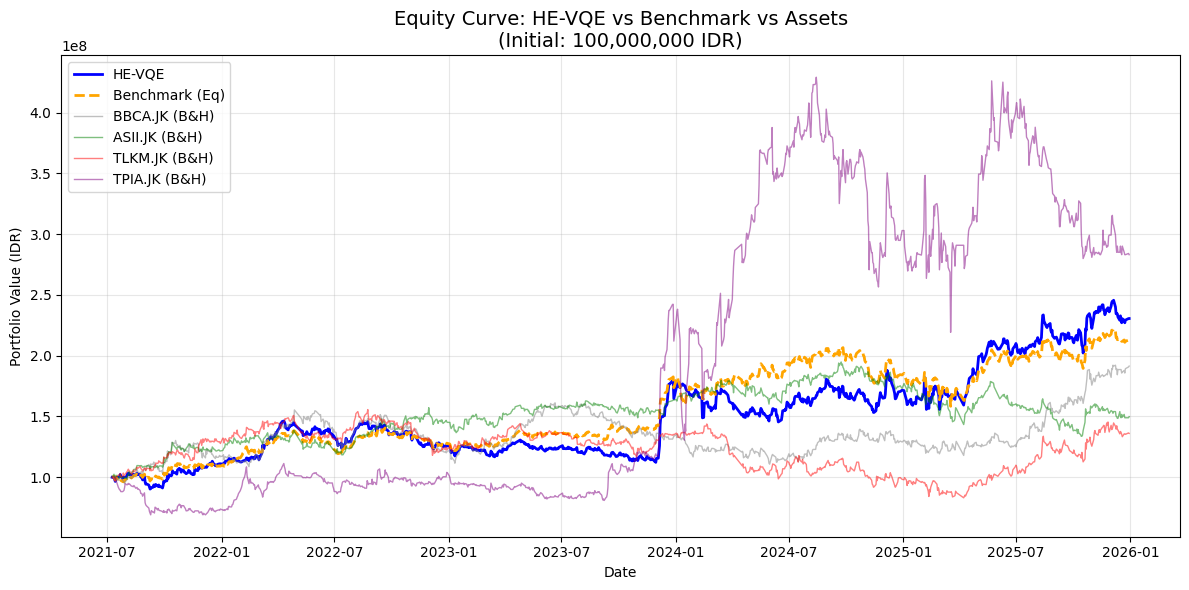


Performance Metrics:
 Strategy Total Return Sharpe Ratio Max Drawdown
   HE-VQE      130.87%       0.8691      -23.34%
Benchmark      113.33%       0.9694      -23.39%
  BBCA.JK       91.66%       0.6874      -31.33%
  ASII.JK       49.98%       0.5239      -31.41%
  TLKM.JK       36.17%       0.3944      -46.69%
  TPIA.JK      183.50%       0.7241      -48.94%


In [11]:
# Create DataFrame for results
df_res = pd.DataFrame(index=dates, data={
    'VQE Strategy': value_vqe,
    'Benchmark': value_bench
})
for t in tickers:
    df_res[t] = value_assets[t]

# Trim to backtest period
df_res = df_res.iloc[start_idx:]

# === Visualisasi ===
plt.figure(figsize=(12, 6))
plt.plot(df_res.index, df_res['VQE Strategy'], label='HE-VQE', linewidth=2, color='blue')
plt.plot(df_res.index, df_res['Benchmark'], label='Benchmark (Eq)', linewidth=2, color='orange', linestyle='--')

# Plot individual assets (faint lines)
colors = ['grey', 'green', 'red', 'purple']
for idx, t in enumerate(tickers):
    plt.plot(df_res.index, df_res[t], label=f'{t} (B&H)', linewidth=1, alpha=0.5, color=colors[idx])

plt.title(f'Equity Curve: HE-VQE vs Benchmark vs Assets\n(Initial: {initial_capital:,.0f} IDR)', fontsize=14)
plt.ylabel('Portfolio Value (IDR)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('backtest_equity_curve.png')
plt.show()

# === Calculate Metrics ===
def calculate_metrics(series, name):
    # Total Return
    tr = (series.iloc[-1] / series.iloc[0]) - 1
    
    # Daily Returns
    daily_rets = series.pct_change().dropna()
    
    # Sharpe (Ann.) - assume rfr=0 for simplicity
    if daily_rets.std() == 0: sharpe = 0
    else: sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252)
    
    # MDD
    roll_max = series.cummax()
    drawdown = (series - roll_max) / roll_max
    mdd = drawdown.min()
    
    return {
        'Strategy': name,
        'Total Return': f"{tr*100:.2f}%",
        'Sharpe Ratio': f"{sharpe:.4f}",
        'Max Drawdown': f"{mdd*100:.2f}%"
    }

metrics = []
metrics.append(calculate_metrics(df_res['VQE Strategy'], 'HE-VQE'))
metrics.append(calculate_metrics(df_res['Benchmark'], 'Benchmark'))
for t in tickers:
    metrics.append(calculate_metrics(df_res[t], t))

df_metrics = pd.DataFrame(metrics)
print("\nPerformance Metrics:")
print(df_metrics.to_string(index=False))